## Project Objective

The objective of this project is to develop a machine learning model for automatic sentiment classification of Russian-language texts.

The project covers the complete NLP workflow, from loading and exploring the dataset to text preprocessing, feature extraction using TF-IDF, model training, and performance evaluation.

The following tasks will be completed as part of the project:

- exploring the structure and quality of the dataset;
- analyzing the distribution of target classes;
- preparing text data for machine learning;
- transforming text into numerical features using TF-IDF;
- training a Logistic Regression model for sentiment classification;
- evaluating model performance using Accuracy, Precision, Recall, and F1-score;
- analyzing the Confusion Matrix;
- examining examples where the model makes incorrect predictions;
- testing the trained model on new user-provided texts;
- experimenting with vectorization parameters and comparing model performance.

The final result will be a model capable of receiving a new text as input and predicting its sentiment, along with an analysis of the factors that influence classification performance.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [30]:
# import dataset
dataset = load_dataset("ai-forever/kinopoisk-sentiment-classification")
print(dataset)
print(dataset["train"].features['label_text'])
dataset["train"].unique("label_text")

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 10500
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 1500
    })
})
Value('string')


['Good', 'Bad', 'Neutral']

In [31]:
# convert the training split to a pandas DataFrame
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()
val_df = dataset['validation'].to_pandas()

In [32]:
# show the first 5 rows
train_df.head(5)

,id,text,label,label_text
0,0,"Если честно, меня не очень впечатлила новость,...",2,Good
1,1,"Сразу скажу — книгу я не читала, поэтому о том...",0,Bad
2,2,Общее впечатление таково: фильм не назовешь пл...,1,Neutral
3,3,Только что посмотрела этот «фильм». Рецензии п...,0,Bad
4,4,"Скажу сразу же, фильм — гениален! Если есть те...",2,Good


In [33]:
# inspect the dataset features
dataset["train"].features

{'id': Value('string'),
 'text': Value('string'),
 'label': Value('int64'),
 'label_text': Value('string')}

In [34]:
# store the column names in variables, so the rest of the notebook does not depend on hard-coded strings
TEXT_COL = "text"
LABEL_COL = "label"
LABEL_TEXT_COL = "label_text"

print(train_df[TEXT_COL].head(5))
print("-" * 100)
print(train_df[LABEL_TEXT_COL].head(5))

0    Если честно, меня не очень впечатлила новость,...
1    Сразу скажу — книгу я не читала, поэтому о том...
2    Общее впечатление таково: фильм не назовешь пл...
3    Только что посмотрела этот «фильм». Рецензии п...
4    Скажу сразу же, фильм — гениален! Если есть те...
Name: text, dtype: str
----------------------------------------------------------------------------------------------------
0       Good
1        Bad
2    Neutral
3        Bad
4       Good
Name: label_text, dtype: str


In [35]:
# find the unique values of the target column
print(train_df[LABEL_COL].unique())
print(train_df[LABEL_TEXT_COL].unique())

# derive the label -> name mapping from the data instead of assuming it
LABEL_NAMES = (train_df[[LABEL_COL, LABEL_TEXT_COL]]
               .drop_duplicates()
               .sort_values(LABEL_COL)
               .set_index(LABEL_COL)[LABEL_TEXT_COL]
               .to_dict())
print(LABEL_NAMES)

[2 0 1]
<ArrowStringArray>
['Good', 'Bad', 'Neutral']
Length: 3, dtype: str
{0: 'Bad', 1: 'Neutral', 2: 'Good'}


In [36]:
# count how many samples belong to each class
class_counts = train_df[LABEL_TEXT_COL].value_counts()
print(class_counts)

label_text
Good       3500
Bad        3500
Neutral    3500
Name: count, dtype: int64


label_text
Good       0.333
Bad        0.333
Neutral    0.333
Name: proportion, dtype: float64


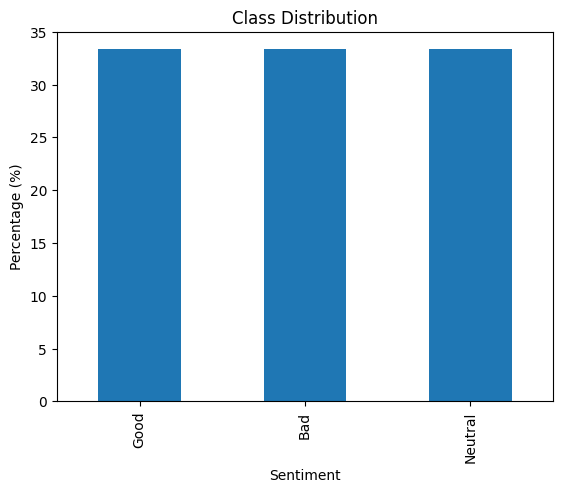

In [37]:
# check class balance
# Print the proportion of each class and draw a bar chart.
class_shares = train_df[LABEL_TEXT_COL].value_counts(normalize=True)
print(class_shares.round(3))

(class_shares * 100).plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Percentage (%)")
plt.show()

In [38]:
# look for missing values in the text and label columns
print(train_df.isna().sum())

id            0
text          0
label         0
label_text    0
dtype: int64


In [39]:
# print a few full reviews of each class
for label_name in train_df[LABEL_TEXT_COL].unique():
    sample = train_df[train_df[LABEL_TEXT_COL] == label_name].iloc[0]
    print(sample[LABEL_TEXT_COL].upper())
    print(sample[TEXT_COL])
    print("-" * 100)

GOOD
Если честно, меня не очень впечатлила новость, о том, что Гай Ричи собирается снять фильм, о Шерлоке Холмсе. Подумал — да это же будет: Карты, деньги, два ствола — у Холмса и у Ватсона. Но затем по мере появления трейлеров, и большей информации поменял своё отношение.
«Шерлок Холмс» — последняя картина, на которую я планировал пойти в этом году. Жутко боялся, что она меня разочарует т. к. перед этим были расстроившие «Безумный спецназ», «Так себе каникулы» и немного 2012. Но Холмс полностью оправдал доверия.
Сюжет
В ленте динамичный, а главное интересный и захватывающий сюжет, что в последнее время не так уж и часто. Новый Холмс не поход классический образ представленный в картинах Игоря Масленникова, но это не портит его образ. Он больше подобен на Тони Старку из «Железного человека» или Грегори Хаусу из сериала «Доктор Хаус». Как и они, он весьма харизматичен, слегка безумен, но гениален в своём любимом деле.
На первый взгляд сюжет портит сверхъестественное восстание из могилы л

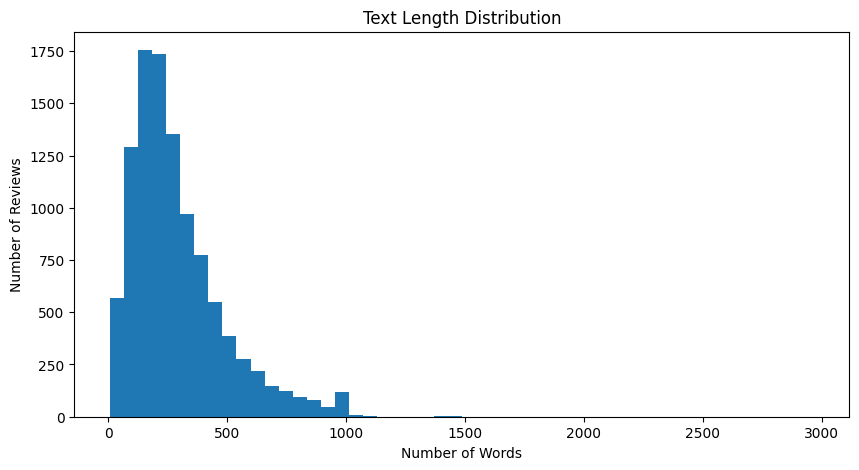

In [40]:
# print a text length of each class.
train_df["text_length"] = train_df[TEXT_COL].str.split().str.len()

plt.figure(figsize=(10, 5))
plt.hist(train_df["text_length"], bins=50)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

In [41]:
# print duplicates
print("duplicated texts:", train_df[TEXT_COL].duplicated().sum())
print("fully duplicated rows:", train_df.duplicated(subset=[TEXT_COL, LABEL_COL]).sum())

duplicated texts: 0
fully duplicated rows: 0


In [42]:
print(train_df["text_length"].describe())

count    10500.000000
mean       288.452190
std        199.116615
min          5.000000
25%        151.000000
50%        239.000000
75%        373.250000
max       2969.000000
Name: text_length, dtype: float64


In [43]:
# look for empty or whitespace-only texts
# NOTE: "".isspace() is False, so str.isspace() alone misses truly empty strings
print("empty or whitespace-only texts:", (train_df[TEXT_COL].str.strip() == "").sum())

empty or whitespace-only texts: 0


In [44]:
# check the data types of the columns
print(train_df.dtypes)

id               str
text             str
label          int64
label_text       str
text_length    int64
dtype: object


In [45]:
# create X_train, y_train, X_test, y_test , X_val, y_val.

X_train, y_train = train_df[TEXT_COL], train_df[LABEL_COL]
X_val, y_val = val_df[TEXT_COL], val_df[LABEL_COL]
X_test, y_test = test_df[TEXT_COL], test_df[LABEL_COL]

In [46]:
splits = [("train", X_train, y_train),
          ("val", X_val, y_val),
          ("test", X_test, y_test)]

for name, x, y in splits:
    print(f"{name} | objects: {len(x)} | X and y aligned: {len(x) == len(y)}")
    print(y.value_counts(normalize=True).sort_index().round(3).to_dict())
    print("-" * 60)

train | objects: 10500 | X and y aligned: True
{0: 0.333, 1: 0.333, 2: 0.333}
------------------------------------------------------------
val | objects: 1500 | X and y aligned: True
{0: 0.333, 1: 0.333, 2: 0.333}
------------------------------------------------------------
test | objects: 1500 | X and y aligned: True
{0: 0.333, 1: 0.333, 2: 0.333}
------------------------------------------------------------


In [47]:
# create the vectorizer and fit it on the training texts.
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [48]:
# print the shapes and check that they match y_train / y_test
print(f"shape X_train:", X_train_tfidf.shape)
print(f"shape X_test:", X_test_tfidf.shape)
print(f"shape [0] X_test: {X_test_tfidf.shape[0]}, len Y_test - {len(y_test)}")
print(f"shape [0] X_train: {X_train_tfidf.shape[0]}, len X_train - {len(X_train)}")

shape X_train: (10500, 160029)
shape X_test: (1500, 160029)
shape [0] X_test: 1500, len Y_test - 1500
shape [0] X_train: 10500, len X_train - 10500


In [49]:
# print a few items from vectorizer.vocabulary_
list(vectorizer.vocabulary_.items())[:10]

[('если', 35153),
 ('честно', 154733),
 ('меня', 62481),
 ('не', 70962),
 ('очень', 88767),
 ('впечатлила', 19252),
 ('новость', 77581),
 ('том', 140935),
 ('что', 155231),
 ('гай', 24032)]

In [50]:
# print feature names via get_feature_names_out()
features_names = vectorizer.get_feature_names_out()
# 5. Print feature names via get_feature_names_out()
print("total features:", len(features_names))
print("first 20:", features_names[:20])

total features: 160029
first 20: ['00' '000' '0000' '00000000000000000000000001' '0000000000000000000001'
 '007' '008' '00х' '01' '023' '03' '04' '05' '050' '06' '07' '08' '09'
 '093' '10']


In [51]:
# compute the sparsity of the training matrix
rows, cols = X_train_tfidf.shape
total_cells = rows * cols
filled = X_train_tfidf.nnz / total_cells

print(f"shape:           {X_train_tfidf.shape}")
print(f"non-zero values: {X_train_tfidf.nnz:,}")
print(f"total cells:     {total_cells:,}")
print(f"filled: {filled * 100:.4f}%   |   zeros: {(1 - filled) * 100:.4f}%")
print(f"average non-zero per review: {X_train_tfidf.nnz / rows:.1f}")

shape:           (10500, 160029)
non-zero values: 2,087,699
total cells:     1,680,304,500
filled: 0.1242%   |   zeros: 99.8758%
average non-zero per review: 198.8


In [52]:
# find 10 words with the lowest and 10 with the highest IDF
idf = vectorizer.idf_
order = np.argsort(idf)          # indices sorted by IDF, ascending

print("LOWEST IDF (the most common words in the corpus):")
for i in order[:10]:
    print(f"   {features_names[i]:12s} idf = {idf[i]:.4f}")

print("\nHIGHEST IDF (the rarest words):")
for i in order[-10:]:
    print(f"   {features_names[i]:26s} idf = {idf[i]:.4f}")

LOWEST IDF (the most common words in the corpus):
   не           idf = 1.0346
   что          idf = 1.0870
   на           idf = 1.1178
   фильм        idf = 1.1747
   но           idf = 1.1767
   это          idf = 1.2023
   как          idf = 1.2453
   то           idf = 1.2581
   все          idf = 1.4281
   так          idf = 1.4578

HIGHEST IDF (the rarest words):
   103е                       idf = 9.5661
   100500                     idf = 9.5661
   10001                      idf = 9.5661
   ёся                        idf = 9.5661
   008                        idf = 9.5661
   ёшка                       idf = 9.5661
   0000000000000000000001     idf = 9.5661
   ёще                        idf = 9.5661
   00000000000000000000000001 idf = 9.5661
   0000                       idf = 9.5661


In [53]:
# Build, train and apply the model.
model = LogisticRegression(max_iter=1000, random_state=42)

# train model
clf = model.fit(X_train_tfidf, y_train)

# make predictions
y_pred = clf.predict(X_test_tfidf)

In [54]:
# check that len(y_pred) == len(y_test) and look at the first 20 predictions
print('len(y_pred) == len(y_test)? - ', len(y_pred) == len(y_test))
print(y_pred[:20])

len(y_pred) == len(y_test)? -  True
[0 0 0 1 0 0 2 2 2 2 1 1 1 2 1 1 1 0 0 0]


In [55]:
# Look at predict_proba for a few test samples
proba = model.predict_proba(X_test_tfidf[:5])

proba_df = pd.DataFrame(proba, columns=[LABEL_NAMES[c] for c in model.classes_])
proba_df["predicted"] = [LABEL_NAMES[c] for c in y_pred[:5]]
proba_df["true"] = [LABEL_NAMES[c] for c in y_test[:5]]
proba_df.round(3)

,Bad,Neutral,Good,predicted,true
0,0.449,0.393,0.158,Bad,Neutral
1,0.727,0.247,0.026,Bad,Bad
2,0.782,0.137,0.081,Bad,Bad
3,0.276,0.406,0.318,Neutral,Neutral
4,0.861,0.124,0.015,Bad,Bad


In [56]:
# print the 20 most positive and the 20 most negative words according to the model.
feature_names = vectorizer.get_feature_names_out()

for row, cls in enumerate(model.classes_):
    weights = model.coef_[row]
    order = np.argsort(weights)

    print(f"--- class {cls} ({LABEL_NAMES[cls]}) ---")
    print("  toward :", [feature_names[i] for i in order[-20:][::-1]])
    print("  against:", [feature_names[i] for i in order[:20]])
    print()

--- class 0 (Bad) ---
  toward : ['зачем', 'вообще', 'абсолютно', 'не', 'ничего', 'увы', 'бред', 'деньги', 'снимать', 'понимаю', 'никак', 'снять', 'вместо', 'видимо', 'нет', 'было', 'сценарий', 'создатели', 'единственное', 'пэрис']
  against: ['очень', 'жизнь', 'жизни', 'он', 'каждый', 'его', 'мир', 'немного', 'отлично', 'действительно', 'главное', 'есть', 'стоит', 'именно', 'ты', 'потрясающий', 'приятно', 'роль', 'великолепно', 'несмотря']

--- class 1 (Neutral) ---
  toward : ['целом', 'стороны', 'неплохой', 'хороший', 'довольно', 'по', 'есть', 'неплохо', 'но', 'джокер', 'красиво', 'своем', 'спейси', 'моменты', 'большего', 'то', 'претензий', 'могу', 'местами', 'особенно']
  against: ['этот', 'абсолютно', 'ведь', 'вы', 'после', 'снять', 'просмотру', 'сценарий', 'бред', 'нам', 'которые', 'ней', 'настолько', 'фильме', 'эмоции', 'здесь', 'слова', 'это', 'будут', 'минуты']

--- class 2 (Good) ---
  toward : ['каждый', 'очень', 'он', 'отлично', 'потрясающий', 'именно', 'великолепный', 'иде

In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score

# compute precision, recall and f1 with macro / micro / weighted averaging.
for avg in ["macro", "micro", "weighted"]:
    p = precision_score(y_test, y_pred, average=avg)
    r = recall_score(y_test, y_pred, average=avg)
    f = f1_score(y_test, y_pred, average=avg)
    print(f"{avg:9s}  precision={p:.3f}  recall={r:.3f}  f1={f:.3f}")

macro      precision=0.662  recall=0.671  f1=0.664
micro      precision=0.671  recall=0.671  f1=0.671
weighted   precision=0.662  recall=0.671  f1=0.664


In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=[LABEL_NAMES[c] for c in model.classes_]))

              precision    recall  f1-score   support

         Bad       0.73      0.79      0.76       500
     Neutral       0.56      0.46      0.51       500
        Good       0.69      0.76      0.72       500

    accuracy                           0.67      1500
   macro avg       0.66      0.67      0.66      1500
weighted avg       0.66      0.67      0.66      1500



In [59]:
# compute the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[396  86  18]
 [118 231 151]
 [ 27  94 379]]


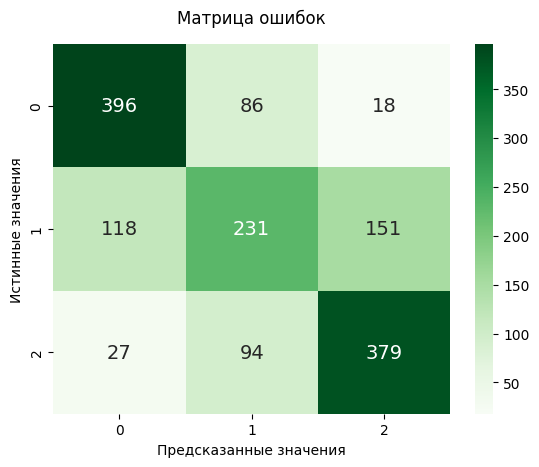

In [61]:
# plot the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', annot_kws={'fontsize': 14})
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок', pad=15)
plt.show()

[[0.792 0.172 0.036]
 [0.236 0.462 0.302]
 [0.054 0.188 0.758]]


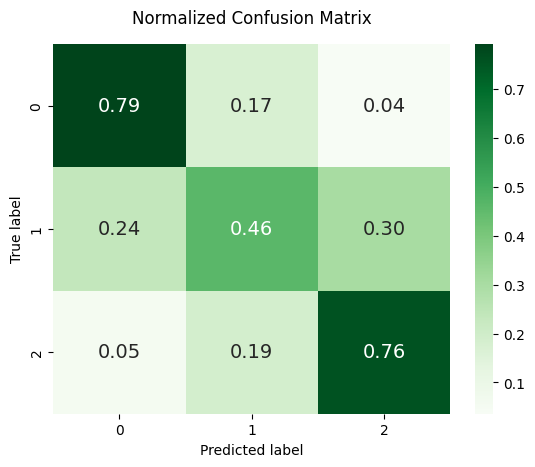

In [62]:
# plot the normalized version
cm_normalized = confusion_matrix(y_test,y_pred,normalize="true")

print(cm_normalized)

# Plot normalized confusion matrix
sns.heatmap(cm_normalized,annot=True,fmt=".2f",cmap="Greens",annot_kws={"fontsize": 14})

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("Normalized Confusion Matrix", pad=15)
plt.show()

In [63]:
# build a DataFrame with columns: text, true, prediction
results_df = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "prediction": y_pred
})
print(results_df)

                                                   text  true  prediction
0     Шла на сеанс, не ожидая ничего сверхъестествен...     1           0
1     Сегодня смотрел этот фильм, если конечно к «эт...     0           0
2     Не смог удержатся и не написать лестный отзыв ...     0           0
3     Фильм-история. Сюжет привлекает внимание, это ...     1           1
4     Есть одна фраза, высказанная свободным питерск...     0           0
...                                                 ...   ...         ...
1495  Действительно, фильм гениальной по сюжету, акт...     1           2
1496  Помоги нам боже пережить этот позор российской...     0           0
1497  Однажды, спасаясь от гангстеров, в маленький а...     2           2
1498  - Эдит, ты не можешь это сделать!\n- Как это н...     2           2
1499  Прочитав множество отрицательных отзывов о нов...     0           0

[1500 rows x 3 columns]


In [64]:
# keep only the rows where true != prediction, print how many there are
errors_df = results_df[results_df['true']!=results_df['prediction']]
print(len(errors_df))

494


In [65]:
# check how confident the model was on its mistakes
error_mask = np.array(y_test) != np.array(y_pred)

# Get probabilities only for mistakes
error_proba = model.predict_proba(X_test_tfidf[error_mask])

# Copy the error dataframe
errors_with_proba = errors_df.copy().reset_index(drop=True)

# Add model confidence
errors_with_proba["confidence"] = error_proba.max(axis=1)

errors_with_proba[
    ["text", "true", "prediction", "confidence"]
].head(10)

,text,true,prediction,confidence
0,"Шла на сеанс, не ожидая ничего сверхъестествен...",1,0,0.449305
1,До просмотра этого фильма я слышал много разли...,1,2,0.761945
2,Как будто тандему сценаристов-продюсеров-режис...,0,1,0.615732
3,На самом деле меня фильм порадовал и на мой вз...,2,1,0.493469
4,Очень красивый фильм. Больше всего понравились...,1,2,0.596389
5,"Мне самому страшно сейчас такое говорить, но У...",1,0,0.551092
6,"Наверное я не так разочарован в этом фильме, п...",1,0,0.481341
7,"Роберт Дауни действительно вжился в роль, но п...",1,2,0.669827
8,"Когда смотрела фильм, поймала себя на мысли — ...",1,2,0.553998
9,"Фильм потрясающий! Что ни говори, а Питер Джек...",1,2,0.584134


In [66]:
# compare the average length of correct vs incorrect predictions
results_df["text_length"] = results_df["text"].str.split().str.len()

# Mark correct and incorrect predictions
results_df["is_correct"] = results_df["true"] == results_df["prediction"]

# Compare average text length
results_df.groupby("is_correct")["text_length"].mean()

is_correct
False    282.076923
True     288.948310
Name: text_length, dtype: float64